In [6]:
import pandas as pd

In [7]:
file_path = "medical_students_dataset.csv"
df = pd.read_csv(file_path)

In [8]:
# Vis en oversigt over manglende værdier per kolonne
missing_summary = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)
# Kombineret visning
missing_info = pd.DataFrame({
    "Missing Values": missing_summary,
    "Percentage (%)": missing_percentage
}).sort_values(by="Missing Values", ascending=False)

df_shape = df.shape

missing_info, df_shape


(                Missing Values  Percentage (%)
 Student ID               20000            10.0
 Age                      20000            10.0
 Gender                   20000            10.0
 Height                   20000            10.0
 Weight                   20000            10.0
 Blood Type               20000            10.0
 BMI                      20000            10.0
 Temperature              20000            10.0
 Heart Rate               20000            10.0
 Blood Pressure           20000            10.0
 Cholesterol              20000            10.0
 Diabetes                 20000            10.0
 Smoking                  20000            10.0,
 (200000, 13))

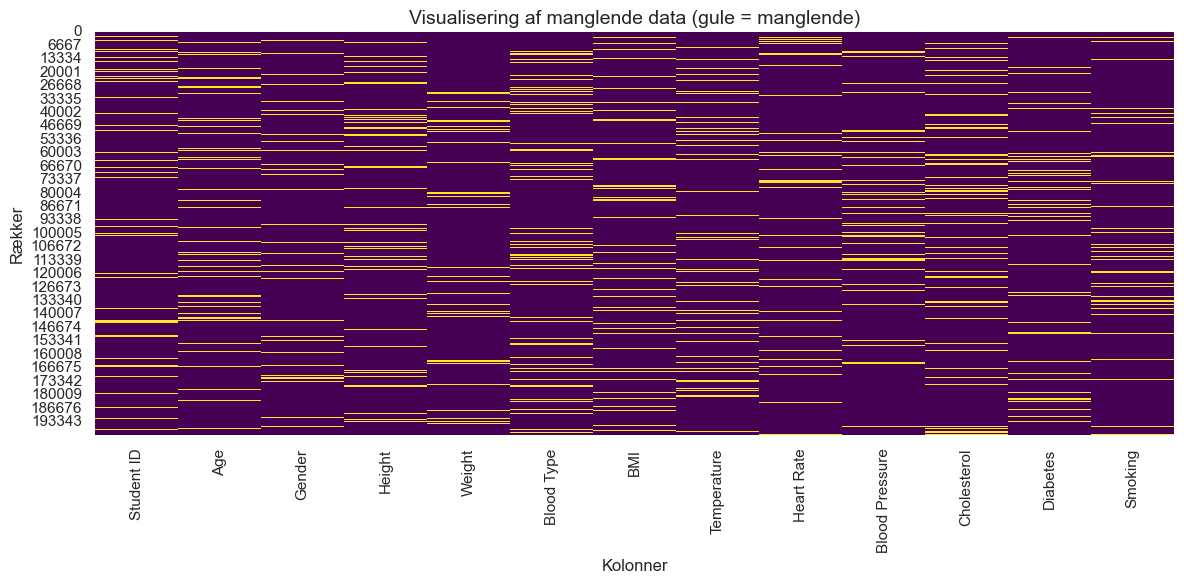

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sæt en flot stil
sns.set(style="whitegrid")

# Heatmap: hvor er data manglende?
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Visualisering af manglende data (gule = manglende)", fontsize=14)
plt.xlabel("Kolonner")
plt.ylabel("Rækker")
plt.tight_layout()
plt.show()


In [10]:
#Opgave 2: Dataimputering og Klassificering
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [11]:
df = pd.read_csv("medical_students_dataset.csv")


In [13]:
# 3. Vælg features og målvariabel

features = ["Age", "BMI", "Blood Pressure", "Cholesterol"]
target = "Diabetes"

# Fjern rækker hvor målet mangler
df_model = df[features + [target]].dropna(subset=[target])


In [14]:
# 4. Konverter 'Diabetes' til numerisk
label_encoder = LabelEncoder()
df_model[target] = label_encoder.fit_transform(df_model[target])


In [15]:
# 5. Lav et lille udsnit (fx 5000 rækker)
df_model = df_model.head(5000)



In [17]:
# 6. Split data i train/test
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 7. Imputer med mean
mean_imputer = SimpleImputer(strategy="mean")
X_train_mean = mean_imputer.fit_transform(X_train)
X_test_mean = mean_imputer.transform(X_test)

In [19]:
#8. Imputér med KNN
knn_imputer = KNNImputer(n_neighbors=5)
X_train_knn = knn_imputer.fit_transform(X_train)
X_test_knn = knn_imputer.transform(X_test)


In [20]:
#9. Træn Random Forest og sammenlign
# Mean
clf_mean = RandomForestClassifier()
clf_mean.fit(X_train_mean, y_train)
acc_mean = accuracy_score(y_test, clf_mean.predict(X_test_mean))

# KNN
clf_knn = RandomForestClassifier()
clf_knn.fit(X_train_knn, y_train)
acc_knn = accuracy_score(y_test, clf_knn.predict(X_test_knn))

print(f"Accuracy (Mean): {acc_mean:.2f}")
print(f"Accuracy (KNN): {acc_knn:.2f}")


Accuracy (Mean): 0.90
Accuracy (KNN): 0.90


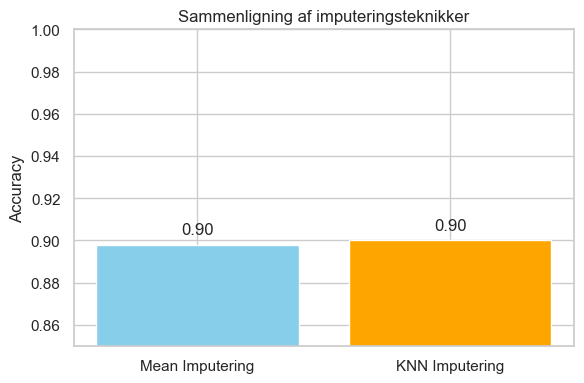

In [21]:
import matplotlib.pyplot as plt

# Data til plot
methods = ['Mean Imputering', 'KNN Imputering']
accuracies = [acc_mean, acc_knn]

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(methods, accuracies, color=['skyblue', 'orange'])
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('Sammenligning af imputeringsteknikker')

# Vis værdi på toppen
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.005, f'{height:.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


F1-score (Mean imputering): 0.02
F1-score (KNN imputering): 0.02


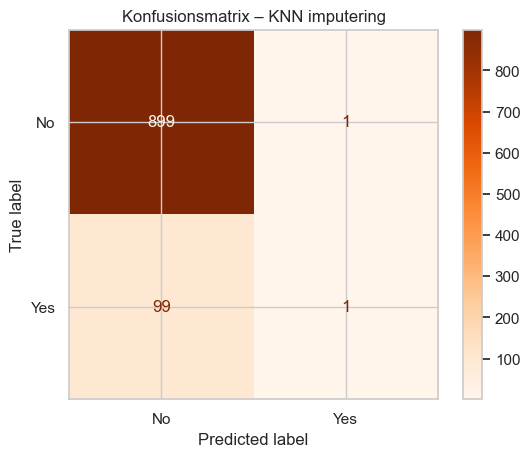

In [22]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# F1-score
f1_mean = f1_score(y_test, clf_mean.predict(X_test_mean))
f1_knn = f1_score(y_test, clf_knn.predict(X_test_knn))

print(f"F1-score (Mean imputering): {f1_mean:.2f}")
print(f"F1-score (KNN imputering): {f1_knn:.2f}")

# Konfusionsmatrix – KNN eksempel
cm_knn = confusion_matrix(y_test, clf_knn.predict(X_test_knn))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=label_encoder.classes_)
disp.plot(cmap='Oranges')
plt.title("Konfusionsmatrix – KNN imputering")
plt.show()


In [23]:
from sklearn.linear_model import LogisticRegression

# Træn logistisk regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_mean, y_train)

# Prædiktion og evaluering
y_pred_logreg = logreg.predict(X_test_mean)

acc_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print(f"Logistic Regression – Accuracy: {acc_logreg:.2f}")
print(f"Logistic Regression – F1-score: {f1_logreg:.2f}")


Logistic Regression – Accuracy: 0.90
Logistic Regression – F1-score: 0.00


In [ ]:
#Regressionsimputering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Lav en kopi af datasættet
df_vis = df.copy()

# Behold kun BMI og Height
df_vis = df_vis[["Height", "BMI"]]

# Split i kendte og manglende BMI-værdier
known = df_vis[df_vis["BMI"].notnull()]
missing = df_vis[df_vis["BMI"].isnull()]


In [ ]:
#  Mean Imputering
mean_value = known["BMI"].mean()
missing_mean = missing.copy()
missing_mean["BMI"] = mean_value

In [42]:
#  Regressionsimputering
# Træn lineær regression på de kendte værdier
reg = LinearRegression()
reg.fit(known[["Height"]], known["BMI"])

LinearRegression()

In [43]:
# Forudsig BMI for manglende værdier baseret på Height
missing_reg = missing.copy()
missing_reg["BMI"] = reg.predict(missing[["Height"]])

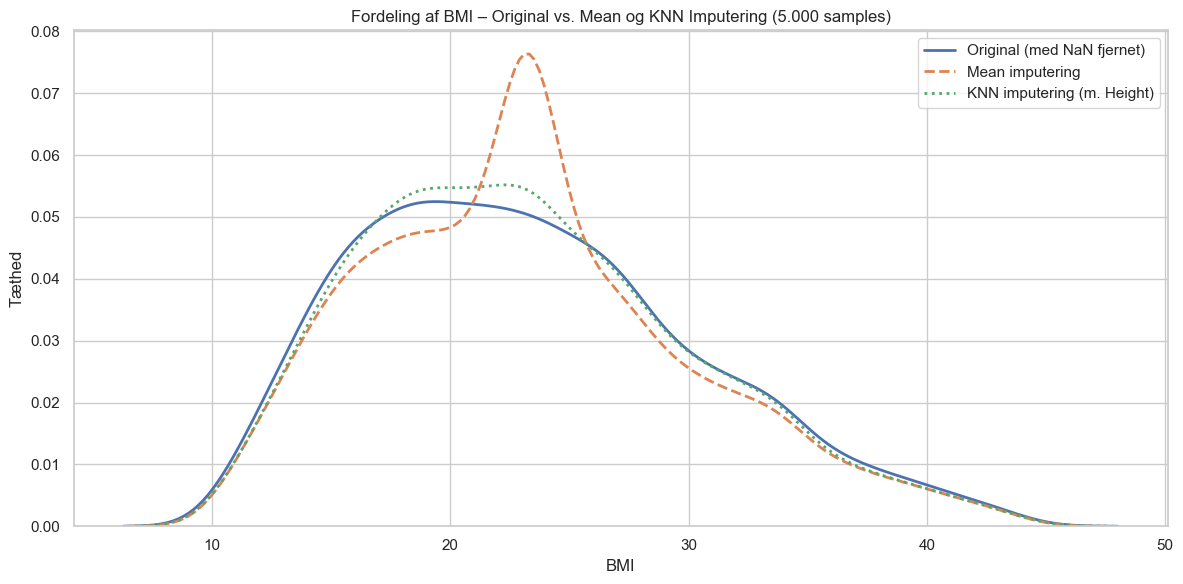

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

# 1. Indlæs datasættet
df = pd.read_csv("medical_students_dataset.csv")

# 2. Tag kun de relevante kolonner
df_sample = df[['Height', 'BMI']].sample(n=5000, random_state=42)

# 3. Mean Imputering
bmi_mean_imputed = df_sample['BMI'].fillna(df_sample['BMI'].mean())

# 4. KNN Imputering
imputer = KNNImputer(n_neighbors=5)
knn_result = imputer.fit_transform(df_sample)
bmi_knn_imputed = pd.DataFrame(knn_result, columns=['Height', 'BMI'])['BMI']

# 5. Visualisering
plt.figure(figsize=(12, 6))
sns.kdeplot(df_sample['BMI'].dropna(), label='Original (med NaN fjernet)', linewidth=2)
sns.kdeplot(bmi_mean_imputed, label='Mean imputering', linestyle='--', linewidth=2)
sns.kdeplot(bmi_knn_imputed, label='KNN imputering (m. Height)', linestyle=':', linewidth=2)
plt.title("Fordeling af BMI – Original vs. Mean og KNN Imputering (5.000 samples)")
plt.xlabel("BMI")
plt.ylabel("Tæthed")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\okhro\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\okhro\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


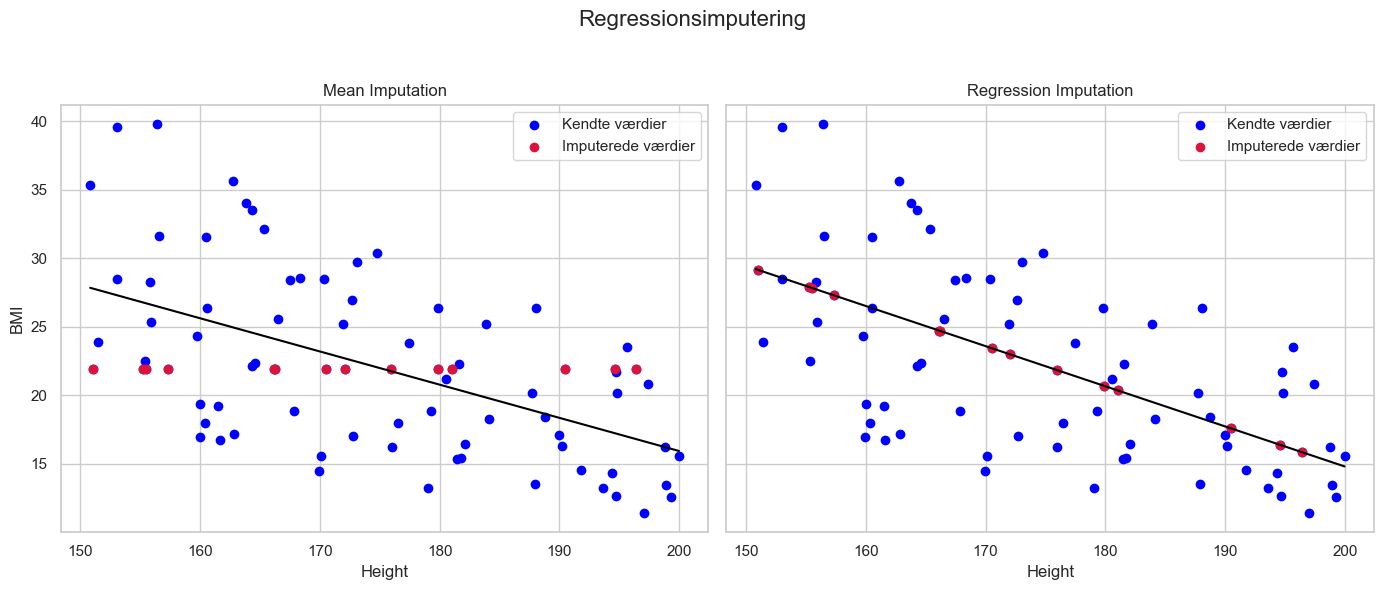

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("medical_students_dataset.csv")

# Tag kun Height og BMI og sample 100 personer
df_sample = df[['Height', 'BMI']].sample(n=100, random_state=42)

# Lav kunstige manglende værdier i BMI
np.random.seed(42)
missing_indices = np.random.choice(df_sample.index, size=15, replace=False)
df_sample.loc[missing_indices, 'BMI'] = np.nan

# 1. Mean Imputation
mean_imputed = df_sample.copy()
mean_value = mean_imputed['BMI'].mean()
mean_imputed.loc[missing_indices, 'BMI'] = mean_value

# 2. Regression Imputation
reg_imputed = df_sample.copy()
known = reg_imputed[reg_imputed['BMI'].notnull() & reg_imputed['Height'].notnull()]
missing = reg_imputed.loc[missing_indices].dropna(subset=['Height'])  # Kun hvor Height findes

reg = LinearRegression()
reg.fit(known[['Height']], known['BMI'])
predicted_bmi = reg.predict(missing[['Height']])
reg_imputed.loc[missing.index, 'BMI'] = predicted_bmi

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Regressionsimputering", fontsize=16)

# Plot Mean Imputation
axes[0].scatter(mean_imputed['Height'], mean_imputed['BMI'], color='blue', label='Kendte værdier')
axes[0].scatter(mean_imputed.loc[missing_indices, 'Height'], mean_imputed.loc[missing_indices, 'BMI'],
                color='crimson', label='Imputerede værdier')
axes[0].set_title("Mean Imputation")
axes[0].set_xlabel("Height")
axes[0].set_ylabel("BMI")

# Fit regressionslinje kun på gyldige data (uden NaN)
valid_mean_data = mean_imputed.dropna(subset=['Height', 'BMI'])
reg_line = LinearRegression()
reg_line.fit(valid_mean_data[['Height']], valid_mean_data['BMI'])
x_vals = np.linspace(valid_mean_data['Height'].min(), valid_mean_data['Height'].max(), 100)
axes[0].plot(x_vals, reg_line.predict(x_vals.reshape(-1, 1)), color='black')

# Plot Regression Imputation
axes[1].scatter(reg_imputed['Height'], reg_imputed['BMI'], color='blue', label='Kendte værdier')
axes[1].scatter(missing['Height'], predicted_bmi, color='crimson', label='Imputerede værdier')
axes[1].set_title("Regression Imputation")
axes[1].set_xlabel("Height")

valid_reg_data = reg_imputed.dropna(subset=['Height', 'BMI'])
reg_line2 = LinearRegression()
reg_line2.fit(valid_reg_data[['Height']], valid_reg_data['BMI'])
axes[1].plot(x_vals, reg_line2.predict(x_vals.reshape(-1, 1)), color='black')

# Fælles settings
for ax in axes:
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()






In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Load data
df = pd.read_csv("medical_students_dataset.csv")

# Drop rows with missing values
df_original = df.dropna()

# Vælg feature-kolonner og target (her bruger vi 'Diabetes' som mål)
X = df_original.drop(columns=['Diabetes', 'Student ID'])  # 'Student ID' er ikke en brugbar feature
y = df_original['Diabetes']

# Gør evt. kategoriske variable numeriske (hvis nødvendigt)
X = pd.get_dummies(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Træn KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prædiktion og evaluering
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label='Yes')  # Antag 'Yes' er positiv klasse

print("🔹 KNN på original data (uden NaN)")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")



🔹 KNN på original data (uden NaN)
Accuracy: 0.89
F1-score: 0.05


In [26]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Load data
df = pd.read_csv("medical_students_dataset.csv")

# 2. Target og features
target_col = 'Diabetes'
features = df.drop(columns=[target_col])
target = df[target_col]

# 3. Find numeriske og kategoriske kolonner
numeric_cols = features.select_dtypes(include='number').columns
categorical_cols = features.select_dtypes(include='object').columns

# 4. Imputer numeriske med mean
mean_imputer = SimpleImputer(strategy='mean')
features_numeric = pd.DataFrame(mean_imputer.fit_transform(features[numeric_cols]), columns=numeric_cols)

# 5. Imputer kategoriske med most frequent
mode_imputer = SimpleImputer(strategy='most_frequent')
features_categorical = pd.DataFrame(mode_imputer.fit_transform(features[categorical_cols]), columns=categorical_cols)

# 6. Konverter tekst til tal med one-hot encoding
features_categorical_encoded = pd.get_dummies(features_categorical, drop_first=True)

# 7. Kombiner numeriske og kategoriske (encoded)
features_final = pd.concat([features_numeric, features_categorical_encoded], axis=1)

# 8. Split data
X_train, X_test, y_train, y_test = train_test_split(features_final, target, test_size=0.2, random_state=42)

# 9. KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 10. Evaluer
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=1)

print(f"✅ Mean Imputering – Accuracy: {acc:.2f}")
print(f"✅ Mean Imputering – F1-score: {f1:.2f}")



ValueError: Input contains NaN

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load data
df = pd.read_csv("medical_students_dataset.csv")

# Encode 'Gender' til numerisk
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # fx Male=1, Female=0

# Brug kun relevante kolonner
features = ['Height', 'BMI']
target = 'Gender'

X = df[features]
y = df[target]

# Mean Imputation + KNN Classifier pipeline
mean_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('classifier', KNeighborsClassifier())
])

# Split og træn model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mean_pipeline.fit(X_train, y_train)

# Evaluer
y_pred = mean_pipeline.predict(X_test)
acc_mean = accuracy_score(y_test, y_pred)

print(f" Accuracy med Mean Imputering: {acc_mean:.2f}")





 Accuracy med Mean Imputering: 0.52


In [29]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv("medical_students_dataset.csv")

# Encode 'Gender' til numerisk
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # fx Male=1, Female=0

# Vælg features og target
features = ['Height', 'BMI']
target = 'Gender'
X = df[features]
y = df[target]

# --- KNN Imputering ---
knn_imputer = KNNImputer(n_neighbors=5)
X_knn = pd.DataFrame(knn_imputer.fit_transform(X), columns=features)

# Split data
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_knn, y, test_size=0.2, random_state=42)

# Træn model
model_k = KNeighborsClassifier()
model_k.fit(X_train_k, y_train_k)

# Evaluer
y_pred_k = model_k.predict(X_test_k)
acc_knn = accuracy_score(y_test_k, y_pred_k)

acc_knn



KeyboardInterrupt: 

In [24]:
#Sampling-imputering
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


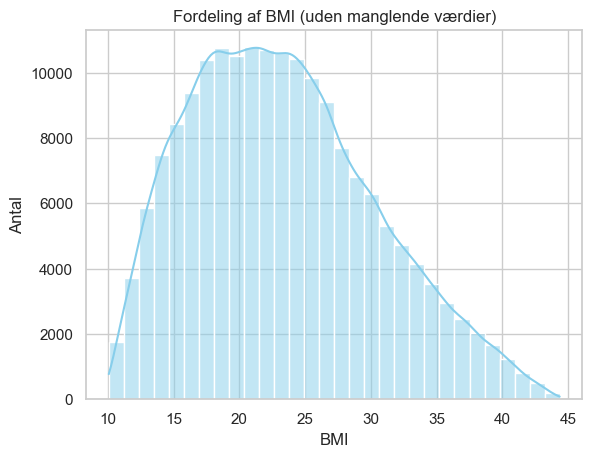

In [25]:
sns.histplot(df["BMI"].dropna(), kde=True, bins=30, color="skyblue")
plt.title("Fordeling af BMI (uden manglende værdier)")
plt.xlabel("BMI")
plt.ylabel("Antal")
plt.show()


In [28]:
mean_bmi = df["BMI"].mean()
std_bmi = df["BMI"].std()



In [29]:
n_missing_bmi = df["BMI"].isnull().sum()
print(f"Antal manglende BMI-værdier: {n_missing_bmi}")



Antal manglende BMI-værdier: 20000


In [30]:
import numpy as np

sampled_bmi = np.random.normal(loc=mean_bmi, scale=std_bmi, size=n_missing_bmi)


In [31]:
# Lav en kopi så vi ikke ændrer originalen
df_sampled = df.copy()

# Find indexer med manglende BMI
missing_bmi_idx = df_sampled[df_sampled["BMI"].isnull()].index

# Erstat med sampled værdier
df_sampled.loc[missing_bmi_idx, "BMI"] = sampled_bmi


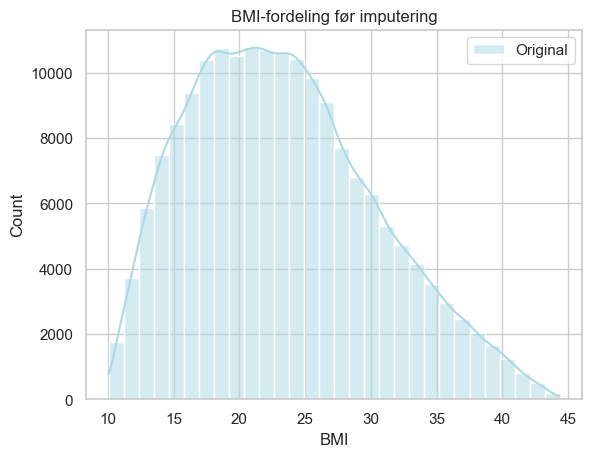

In [32]:
sns.histplot(df["BMI"].dropna(), kde=True, bins=30, color="lightblue", label="Original")
plt.title("BMI-fordeling før imputering")
plt.legend()
plt.show()


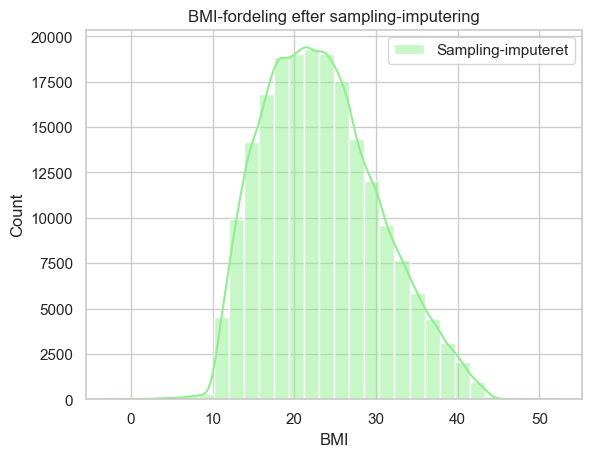

In [33]:
sns.histplot(df_sampled["BMI"], kde=True, bins=30, color="lightgreen", label="Sampling-imputeret")
plt.title("BMI-fordeling efter sampling-imputering")
plt.legend()
plt.show()


In [1]:
import sqlite3

# Forbind til en ny databasefil
conn = sqlite3.connect("workshop_students.db")
cursor = conn.cursor()


In [2]:
# Opret STUDENTS tabel
cursor.execute("""
CREATE TABLE IF NOT EXISTS Students (
    student_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    age INTEGER,
    gender TEXT
)
""")

# Opret HEALTHMETRICS tabel
cursor.execute("""
CREATE TABLE IF NOT EXISTS HealthMetrics (
    record_id INTEGER PRIMARY KEY AUTOINCREMENT,
    student_id INTEGER,
    bmi REAL,
    blood_pressure INTEGER,
    cholesterol INTEGER,
    diabetes TEXT,
    FOREIGN KEY(student_id) REFERENCES Students(student_id)
)
""")

conn.commit()


In [3]:
students = [
    (1, "Emma", 24, "Female"),
    (2, "Lucas", 22, "Male"),
    (3, "Sofia", 23, "Female")
]

metrics = [
    (1, 22.3, 115, 180, "No"),
    (2, 27.8, 135, 210, "Yes"),
    (3, 25.1, 120, 195, "No")
]

cursor.executemany("INSERT INTO Students (student_id, name, age, gender) VALUES (?, ?, ?, ?)", students)

cursor.executemany("""
INSERT INTO HealthMetrics (student_id, bmi, blood_pressure, cholesterol, diabetes)
VALUES (?, ?, ?, ?, ?)
""", metrics)

conn.commit()


In [4]:
cursor.execute("""
SELECT s.name, s.age, h.bmi, h.diabetes
FROM Students s
JOIN HealthMetrics h ON s.student_id = h.student_id
WHERE h.bmi > 25
""")

for row in cursor.fetchall():
    print(row)


('Lucas', 22, 27.8, 'Yes')
('Sofia', 23, 25.1, 'No')


In [5]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS StressLevels (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    student_id INTEGER,
    stress_level INTEGER,  -- fx skala fra 1-10
    FOREIGN KEY(student_id) REFERENCES Students(student_id)
)
""")


In [6]:
stress_data = [
    (1, 3),   # Emma: lav stress
    (2, 8),   # Lucas: høj stress
    (3, 6)    # Sofia: mellem stress
]

cursor.executemany("INSERT INTO StressLevels (student_id, stress_level) VALUES (?, ?)", stress_data)
conn.commit()


In [8]:
cursor.execute("""
SELECT s.name, s.age, sl.stress_level, h.diabetes
FROM Students s
JOIN StressLevels sl ON s.student_id = sl.student_id
JOIN HealthMetrics h ON s.student_id = h.student_id
""")

for row in cursor.fetchall():
    print(row)



('Emma', 24, 3, 'No')
('Lucas', 22, 8, 'Yes')
('Sofia', 23, 6, 'No')


In [9]:
cursor.execute("""
SELECT s.name, s.age, sl.stress_level, h.diabetes
FROM Students s
JOIN StressLevels sl ON s.student_id = sl.student_id
JOIN HealthMetrics h ON s.student_id = h.student_id;
""")

# Fetch and print the results
for row in cursor.fetchall():
    print(row)


('Emma', 24, 3, 'No')
('Lucas', 22, 8, 'Yes')
('Sofia', 23, 6, 'No')


In [4]:
# ✅ Import nødvendige biblioteker
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ✅ Indlæs datasættet
df = pd.read_csv("medical_students_dataset.csv")

# ✅ Vælg de relevante kolonner
features = ["BMI", "Height"]
target = "Diabetes"

# ✅ Fjern rækker hvor target mangler
df = df[features + [target]].dropna(subset=[target])

# ✅ Konverter target (Diabetes) fra tekst til tal
le = LabelEncoder()
df[target] = le.fit_transform(df[target])  # 'Yes'/'No' → 1/0

# ✅ Separér features og labels
X = df[features]
y = df[target]

# ✅ KNN-imputering af manglende værdier
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X)

# ✅ Split datasæt til træning og test
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# ✅ Træn en Random Forest klassifikationsmodel
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ✅ Forudsig og evaluer model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# ✅ Vis resultat
print(f"Model accuracy after KNN-imputering: {accuracy:.2f}")


KeyboardInterrupt: 

In [9]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # Enables experimental feature
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load dataset
df = pd.read_csv("medical_students_dataset.csv")

# ✅ Limit to first 5000 rows
df = df.head(5000)

# 2. Select relevant columns
features = ["BMI", "Height"]
target = "Diabetes"

# 3. Drop rows where target is missing
df = df[features + [target]].dropna(subset=[target])

# 4. Encode target (Yes/No → 1/0)
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# 5. Separate features and labels
X = df[features]
y = df[target]

# 6. Regression-based imputing
reg_imputer = IterativeImputer(random_state=42)
X_imputed = reg_imputer.fit_transform(X)

# 7. Split data
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# 8. Train classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 9. Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy after Regressionsimputering (5000 rows): {accuracy:.2f}")


Model accuracy after Regressionsimputering (5000 rows): 0.89


In [6]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # Aktiver eksperimentel funktion
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Indlæs datasæt
df = pd.read_csv("medical_students_dataset.csv")

# 2. Vælg de relevante kolonner
features = ["BMI", "Height"]
target = "Diabetes"

# 3. Fjern rækker hvor target mangler
df = df[features + [target]].dropna(subset=[target])

# 4. Konverter target (Diabetes) til numerisk
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# 5. Separér X og y
X = df[features]
y = df[target]

# 6. Regressionsimputering (IterativeImputer)
reg_imputer = IterativeImputer(random_state=42)
X_imputed = reg_imputer.fit_transform(X)

# 7. Split datasættet
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# 8. Træn klassifikationsmodel (Random Forest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 9. Evaluer
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy after Regressionsimputering: {accuracy:.2f}")


Model accuracy after Regressionsimputering: 0.94


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Indlæs hele datasættet
df = pd.read_csv("medical_students_dataset.csv")

# 2. Vælg kolonner
features = ["BMI", "Height"]
target = "Diabetes"

# 3. Drop rækker med manglende værdier (uden imputering)
df = df[features + [target]].dropna()

# 4. Label encode target (Yes/No → 1/0)
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# 5. Separér features og target
X = df[features]
y = df[target]

# 6. Split datasæt i træning/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Træn model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 8. Evaluer model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy without imputering (full dataset): {accuracy:.2f}")


Model accuracy without imputering (full dataset): 0.95
